# 🌐 Financial Inclusion Analytics — REST API
### Run, expose, and test the API entirely within Google Colab

**Stack:** Flask + PySpark + pyngrok (public HTTPS tunnel)

---

## API Endpoints

| Method | Path | Description |
|---|---|---|
| GET | `/` | API index |
| GET | `/health` | Health check |
| POST | `/api/load` | Load CSV into Spark |
| GET | `/api/analyze/overview` | Dataset statistics |
| GET | `/api/analyze/fraud` | Fraud analytics by type |
| GET | `/api/analyze/inclusion` | Inclusion segmentation |
| GET | `/api/analyze/mobility` | Economic mobility |
| GET | `/api/analyze/hourly` | Hourly patterns |
| POST | `/api/predict/fraud` | Score a transaction |
| POST | `/api/ml/train` | Train RandomForest model |
| GET | `/api/model/info` | Model metadata |
| POST | `/api/stream/simulate` | Start stream simulation |
| GET | `/api/stream/status` | Stream job status |
| POST | `/api/stream/stop` | Stop stream |
| POST | `/api/batch/full-pipeline` | Full pipeline run |

## ⚙️ Step 1 — Install Dependencies

In [1]:
!apt-get install -y openjdk-11-jdk-headless -qq > /dev/null
!pip install pyspark==3.5.0 pyngrok flask findspark --quiet

import os
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-11-openjdk-amd64'

import findspark
findspark.init()
print('✅ Dependencies ready')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 11.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.0.2 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.0 which is incompatible.
✅ Dependencies ready


## 📁 Step 2 — Upload Dataset & API Script

In [2]:
from google.colab import files

print('Upload financial_api.py:')
uploaded_api = files.upload()
print('✅ API script uploaded:', list(uploaded_api.keys()))

Upload financial_api.py:


Saving financial_api.py to financial_api.py
✅ API script uploaded: ['financial_api.py']


## 🚀 Step 3 — Start the API Server + Public URL

In [3]:
import subprocess, threading, time
from pyngrok import ngrok, conf

# ── Start Flask API in background ─────────────────────────────────────────────
server = subprocess.Popen(
    ['python', 'financial_api.py'],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

time.sleep(4)  # wait for Flask to start

# ── Create public tunnel ───────────────────────────────────────────────────────
# Sign up free at https://ngrok.com to get your authtoken
NGROK_TOKEN = '35HkqtoM55vfT14X35mVGUTTfnM_Tj9uSSJckaE3JZwez65L'  # ← paste your ngrok authtoken here

if NGROK_TOKEN:
    ngrok.set_auth_token(NGROK_TOKEN)

public_url = ngrok.connect(5000)
BASE_URL = str(public_url).replace("NgrokTunnel: ", "").split('"')[0]
if '"' in BASE_URL:
    BASE_URL = BASE_URL.strip('"')

print(f'\n🌐 API is LIVE at: {BASE_URL}')
print(f'   Local:          http://localhost:5000')
print(f'\n   Try it: {BASE_URL}/health')


🌐 API is LIVE at: 
   Local:          http://localhost:5000

   Try it: /health


## 🧪 Step 4 — Test All Endpoints

In [4]:
import requests, json

def call(method, path, body=None, params=None):
    url = f'http://localhost:5000{path}'
    r = getattr(requests, method)(url, json=body, params=params, timeout=120)
    data = r.json()
    print(f'\n{'='*60}')
    print(f'{method.upper()} {path}  →  HTTP {r.status_code}')
    print(json.dumps(data, indent=2)[:1500])
    return data

# ── 4.1  Health check ──────────────────────────────────────────────────────────
call('get', '/health')


GET /health  →  HTTP 200
{
  "data": {
    "active_streams": 0,
    "dataset_loaded": false,
    "spark_running": false,
    "stream_jobs": 0
  },
  "message": "OK",
  "status": "success",
  "timestamp": "2026-04-14T04:22:31.051016Z"
}


{'data': {'active_streams': 0,
  'dataset_loaded': False,
  'spark_running': False,
  'stream_jobs': 0},
 'message': 'OK',
 'status': 'success',
 'timestamp': '2026-04-14T04:22:31.051016Z'}

In [5]:
# ── 4.2  Load dataset ──────────────────────────────────────────────────────────
call('post', '/api/load', {'path': 'financial.csv'})


POST /api/load  →  HTTP 200
{
  "data": {
    "columns": [
      "step",
      "type",
      "amount",
      "nameOrig",
      "oldbalanceOrg",
      "newbalanceOrig",
      "nameDest",
      "oldbalanceDest",
      "newbalanceDest",
      "isFraud",
      "isFlaggedFraud",
      "balance_diff_orig",
      "balance_diff_dest",
      "amount_to_balance_ratio",
      "hour_of_day",
      "day_of_month",
      "is_large_transaction",
      "account_emptied"
    ],
    "features_added": [
      "balance_diff_orig",
      "balance_diff_dest",
      "amount_to_balance_ratio",
      "hour_of_day",
      "day_of_month",
      "is_large_transaction",
      "account_emptied"
    ],
    "path": "financial.csv",
    "total_rows": 2763196
  },
  "execution_time_ms": 53321.1,
  "message": "Dataset loaded successfully",
  "status": "success",
  "timestamp": "2026-04-14T04:23:24.388669Z"
}


{'data': {'columns': ['step',
   'type',
   'amount',
   'nameOrig',
   'oldbalanceOrg',
   'newbalanceOrig',
   'nameDest',
   'oldbalanceDest',
   'newbalanceDest',
   'isFraud',
   'isFlaggedFraud',
   'balance_diff_orig',
   'balance_diff_dest',
   'amount_to_balance_ratio',
   'hour_of_day',
   'day_of_month',
   'is_large_transaction',
   'account_emptied'],
  'features_added': ['balance_diff_orig',
   'balance_diff_dest',
   'amount_to_balance_ratio',
   'hour_of_day',
   'day_of_month',
   'is_large_transaction',
   'account_emptied'],
  'path': 'financial.csv',
  'total_rows': 2763196},
 'execution_time_ms': 53321.1,
 'message': 'Dataset loaded successfully',
 'status': 'success',
 'timestamp': '2026-04-14T04:23:24.388669Z'}

In [6]:
# ── 4.3  Dataset overview ──────────────────────────────────────────────────────
call('get', '/api/analyze/overview')


GET /api/analyze/overview  →  HTTP 200
{
  "data": {
    "amount_statistics": {
      "max": 10000000.0,
      "mean": 156778.57,
      "median": 76695.35,
      "min": 0.0,
      "p75": 211473.7,
      "p95": 507939.66,
      "std": 262568.29
    },
    "fraud_rate_pct": 0.087,
    "time_span_hours": 213,
    "total_fraud": 2405,
    "total_rows": 2763196,
    "transaction_types": [
      {
        "count": 987488,
        "type": "CASH_OUT"
      },
      {
        "count": 922666,
        "type": "PAYMENT"
      },
      {
        "count": 607227,
        "type": "CASH_IN"
      },
      {
        "count": 228411,
        "type": "TRANSFER"
      },
      {
        "count": 17404,
        "type": "DEBIT"
      }
    ]
  },
  "execution_time_ms": 19298.5,
  "message": "OK",
  "status": "success",
  "timestamp": "2026-04-14T04:23:43.793425Z"
}


{'data': {'amount_statistics': {'max': 10000000.0,
   'mean': 156778.57,
   'median': 76695.35,
   'min': 0.0,
   'p75': 211473.7,
   'p95': 507939.66,
   'std': 262568.29},
  'fraud_rate_pct': 0.087,
  'time_span_hours': 213,
  'total_fraud': 2405,
  'total_rows': 2763196,
  'transaction_types': [{'count': 987488, 'type': 'CASH_OUT'},
   {'count': 922666, 'type': 'PAYMENT'},
   {'count': 607227, 'type': 'CASH_IN'},
   {'count': 228411, 'type': 'TRANSFER'},
   {'count': 17404, 'type': 'DEBIT'}]},
 'execution_time_ms': 19298.5,
 'message': 'OK',
 'status': 'success',
 'timestamp': '2026-04-14T04:23:43.793425Z'}

In [7]:
# ── 4.4  Fraud analysis ────────────────────────────────────────────────────────
call('get', '/api/analyze/fraud')


GET /api/analyze/fraud  →  HTTP 200
{
  "data": {
    "fraud_by_type": [
      {
        "account_emptied_count": 418071,
        "avg_amount": 179902.69,
        "fraud_count": 1211,
        "fraud_rate_pct": 0.1226,
        "total_transactions": 987488,
        "total_volume_M": 177651.752,
        "type": "CASH_OUT"
      },
      {
        "account_emptied_count": 98647,
        "avg_amount": 624195.39,
        "fraud_count": 1194,
        "fraud_rate_pct": 0.5227,
        "total_transactions": 228411,
        "total_volume_M": 142573.093,
        "type": "TRANSFER"
      },
      {
        "account_emptied_count": 127072,
        "avg_amount": 11422.94,
        "fraud_count": 0,
        "fraud_rate_pct": 0.0,
        "total_transactions": 922666,
        "total_volume_M": 10539.563,
        "type": "PAYMENT"
      },
      {
        "account_emptied_count": 2272,
        "avg_amount": 5248.06,
        "fraud_count": 0,
        "fraud_rate_pct": 0.0,
        "total_transactions": 

{'data': {'fraud_by_type': [{'account_emptied_count': 418071,
    'avg_amount': 179902.69,
    'fraud_count': 1211,
    'fraud_rate_pct': 0.1226,
    'total_transactions': 987488,
    'total_volume_M': 177651.752,
    'type': 'CASH_OUT'},
   {'account_emptied_count': 98647,
    'avg_amount': 624195.39,
    'fraud_count': 1194,
    'fraud_rate_pct': 0.5227,
    'total_transactions': 228411,
    'total_volume_M': 142573.093,
    'type': 'TRANSFER'},
   {'account_emptied_count': 127072,
    'avg_amount': 11422.94,
    'fraud_count': 0,
    'fraud_rate_pct': 0.0,
    'total_transactions': 922666,
    'total_volume_M': 10539.563,
    'type': 'PAYMENT'},
   {'account_emptied_count': 2272,
    'avg_amount': 5248.06,
    'fraud_count': 0,
    'fraud_rate_pct': 0.0,
    'total_transactions': 17404,
    'total_volume_M': 91.337,
    'type': 'DEBIT'},
   {'account_emptied_count': 0,
    'avg_amount': 168560.0,
    'fraud_count': 0,
    'fraud_rate_pct': 0.0,
    'total_transactions': 607227,
    

In [8]:
# ── 4.5  Financial inclusion segmentation ─────────────────────────────────────
call('get', '/api/analyze/inclusion')


GET /api/analyze/inclusion  →  HTTP 200
{
  "data": {
    "methodology": "Segmentation based on origin account balance at time of transaction. Zero-balance accounts represent the financially excluded population gaining access via mobile money.",
    "segments": [
      {
        "avg_transaction_amount": 169189.79,
        "fraud_count": 24,
        "fraud_rate_pct": 0.0026,
        "income_segment": "Unbanked (Zero Balance)",
        "total_volume_M": 154355.565,
        "transaction_count": 912322,
        "unique_users": 912125
      },
      {
        "avg_transaction_amount": 150149.2,
        "fraud_count": 448,
        "fraud_rate_pct": 0.0582,
        "income_segment": "Middle Income (10K-100K)",
        "total_volume_M": 115505.427,
        "transaction_count": 769271,
        "unique_users": 769145
      },
      {
        "avg_transaction_amount": 148848.63,
        "fraud_count": 1845,
        "fraud_rate_pct": 0.2452,
        "income_segment": "High Income (>100K)",
     

{'data': {'methodology': 'Segmentation based on origin account balance at time of transaction. Zero-balance accounts represent the financially excluded population gaining access via mobile money.',
  'segments': [{'avg_transaction_amount': 169189.79,
    'fraud_count': 24,
    'fraud_rate_pct': 0.0026,
    'income_segment': 'Unbanked (Zero Balance)',
    'total_volume_M': 154355.565,
    'transaction_count': 912322,
    'unique_users': 912125},
   {'avg_transaction_amount': 150149.2,
    'fraud_count': 448,
    'fraud_rate_pct': 0.0582,
    'income_segment': 'Middle Income (10K-100K)',
    'total_volume_M': 115505.427,
    'transaction_count': 769271,
    'unique_users': 769145},
   {'avg_transaction_amount': 148848.63,
    'fraud_count': 1845,
    'fraud_rate_pct': 0.2452,
    'income_segment': 'High Income (>100K)',
    'total_volume_M': 112008.147,
    'transaction_count': 752497,
    'unique_users': 752357},
   {'avg_transaction_amount': 156000.76,
    'fraud_count': 88,
    'fraud

In [9]:
# ── 4.6  Economic mobility ────────────────────────────────────────────────────
call('get', '/api/analyze/mobility')


GET /api/analyze/mobility  →  HTTP 200
{
  "data": {
    "daily_pulse": [
      {
        "active_users": 574184,
        "avg_txn_size": 160437.2,
        "daily_volume_M": 92131.87,
        "day_of_month": 1
      },
      {
        "active_users": 455188,
        "avg_txn_size": 156486.59,
        "daily_volume_M": 71238.64,
        "day_of_month": 2
      },
      {
        "active_users": 1070,
        "avg_txn_size": 417835.96,
        "daily_volume_M": 447.08,
        "day_of_month": 3
      },
      {
        "active_users": 28240,
        "avg_txn_size": 135642.61,
        "daily_volume_M": 3830.55,
        "day_of_month": 4
      },
      {
        "active_users": 9789,
        "avg_txn_size": 135369.68,
        "daily_volume_M": 1325.13,
        "day_of_month": 5
      },
      {
        "active_users": 440962,
        "avg_txn_size": 166460.67,
        "daily_volume_M": 73409.99,
        "day_of_month": 6
      },
      {
        "active_users": 420548,
        "avg_txn_si

{'data': {'daily_pulse': [{'active_users': 574184,
    'avg_txn_size': 160437.2,
    'daily_volume_M': 92131.87,
    'day_of_month': 1},
   {'active_users': 455188,
    'avg_txn_size': 156486.59,
    'daily_volume_M': 71238.64,
    'day_of_month': 2},
   {'active_users': 1070,
    'avg_txn_size': 417835.96,
    'daily_volume_M': 447.08,
    'day_of_month': 3},
   {'active_users': 28240,
    'avg_txn_size': 135642.61,
    'daily_volume_M': 3830.55,
    'day_of_month': 4},
   {'active_users': 9789,
    'avg_txn_size': 135369.68,
    'daily_volume_M': 1325.13,
    'day_of_month': 5},
   {'active_users': 440962,
    'avg_txn_size': 166460.67,
    'daily_volume_M': 73409.99,
    'day_of_month': 6},
   {'active_users': 420548,
    'avg_txn_size': 159470.97,
    'daily_volume_M': 67070.78,
    'day_of_month': 7},
   {'active_users': 449589,
    'avg_txn_size': 155749.19,
    'daily_volume_M': 70030.6,
    'day_of_month': 8},
   {'active_users': 383346,
    'avg_txn_size': 140136.23,
    'dail

In [10]:
# ── 4.7  Hourly patterns ──────────────────────────────────────────────────────
call('get', '/api/analyze/hourly')


GET /api/analyze/hourly  →  HTTP 200
{
  "data": {
    "hourly_breakdown": [
      {
        "avg_amount": 101182.66,
        "fraud_count": 102,
        "hour_of_day": 0,
        "transaction_count": 10929,
        "volume_M": 1105.825
      },
      {
        "avg_amount": 126697.97,
        "fraud_count": 114,
        "hour_of_day": 1,
        "transaction_count": 3632,
        "volume_M": 460.167
      },
      {
        "avg_amount": 191974.59,
        "fraud_count": 78,
        "hour_of_day": 2,
        "transaction_count": 914,
        "volume_M": 175.465
      },
      {
        "avg_amount": 246804.27,
        "fraud_count": 66,
        "hour_of_day": 3,
        "transaction_count": 621,
        "volume_M": 153.265
      },
      {
        "avg_amount": 266281.27,
        "fraud_count": 92,
        "hour_of_day": 4,
        "transaction_count": 751,
        "volume_M": 199.977
      },
      {
        "avg_amount": 150402.61,
        "fraud_count": 98,
        "hour_of_day": 

{'data': {'hourly_breakdown': [{'avg_amount': 101182.66,
    'fraud_count': 102,
    'hour_of_day': 0,
    'transaction_count': 10929,
    'volume_M': 1105.825},
   {'avg_amount': 126697.97,
    'fraud_count': 114,
    'hour_of_day': 1,
    'transaction_count': 3632,
    'volume_M': 460.167},
   {'avg_amount': 191974.59,
    'fraud_count': 78,
    'hour_of_day': 2,
    'transaction_count': 914,
    'volume_M': 175.465},
   {'avg_amount': 246804.27,
    'fraud_count': 66,
    'hour_of_day': 3,
    'transaction_count': 621,
    'volume_M': 153.265},
   {'avg_amount': 266281.27,
    'fraud_count': 92,
    'hour_of_day': 4,
    'transaction_count': 751,
    'volume_M': 199.977},
   {'avg_amount': 150402.61,
    'fraud_count': 98,
    'hour_of_day': 5,
    'transaction_count': 1736,
    'volume_M': 261.099},
   {'avg_amount': 131002.48,
    'fraud_count': 104,
    'hour_of_day': 6,
    'transaction_count': 6929,
    'volume_M': 907.716},
   {'avg_amount': 166755.91,
    'fraud_count': 98,
 

In [11]:
# ── 4.8  Fraud prediction — HIGH RISK transaction ─────────────────────────────
call('post', '/api/predict/fraud', {
    'type':           'TRANSFER',
    'amount':         750000,
    'oldbalanceOrg':  750000,
    'newbalanceOrig': 0,
    'oldbalanceDest': 0,
    'newbalanceDest': 750000
})


POST /api/predict/fraud  →  HTTP 200
{
  "data": {
    "recommendation": "Block and review",
    "risk_level": "HIGH",
    "risk_reasons": [
      "High-risk transaction type (+20)",
      "Account fully drained (+35)",
      "Very large transaction (>500K) (+25)",
      "Transfer to previously empty account (+15)",
      "Amount is >95% of balance (+10)"
    ],
    "risk_score": 100,
    "transaction_summary": {
      "amount": 750000.0,
      "balance_after": 0.0,
      "type": "TRANSFER"
    }
  },
  "execution_time_ms": 0.5,
  "message": "OK",
  "status": "success",
  "timestamp": "2026-04-14T04:24:30.387283Z"
}


{'data': {'recommendation': 'Block and review',
  'risk_level': 'HIGH',
  'risk_reasons': ['High-risk transaction type (+20)',
   'Account fully drained (+35)',
   'Very large transaction (>500K) (+25)',
   'Transfer to previously empty account (+15)',
   'Amount is >95% of balance (+10)'],
  'risk_score': 100,
  'transaction_summary': {'amount': 750000.0,
   'balance_after': 0.0,
   'type': 'TRANSFER'}},
 'execution_time_ms': 0.5,
 'message': 'OK',
 'status': 'success',
 'timestamp': '2026-04-14T04:24:30.387283Z'}

In [12]:
# ── 4.9  Fraud prediction — LOW RISK transaction ──────────────────────────────
call('post', '/api/predict/fraud', {
    'type':           'PAYMENT',
    'amount':         1500,
    'oldbalanceOrg':  25000,
    'newbalanceOrig': 23500,
    'oldbalanceDest': 0,
    'newbalanceDest': 1500
})


POST /api/predict/fraud  →  HTTP 200
{
  "data": {
    "recommendation": "Allow",
    "risk_level": "LOW",
    "risk_reasons": [],
    "risk_score": 0,
    "transaction_summary": {
      "amount": 1500.0,
      "balance_after": 23500.0,
      "type": "PAYMENT"
    }
  },
  "execution_time_ms": 1.1,
  "message": "OK",
  "status": "success",
  "timestamp": "2026-04-14T04:24:30.415677Z"
}


{'data': {'recommendation': 'Allow',
  'risk_level': 'LOW',
  'risk_reasons': [],
  'risk_score': 0,
  'transaction_summary': {'amount': 1500.0,
   'balance_after': 23500.0,
   'type': 'PAYMENT'}},
 'execution_time_ms': 1.1,
 'message': 'OK',
 'status': 'success',
 'timestamp': '2026-04-14T04:24:30.415677Z'}

In [13]:
# ── 4.10 Train ML model ───────────────────────────────────────────────────────
call('post', '/api/ml/train', {
    'num_trees':       100,
    'max_depth':        10,
    'sample_fraction': 0.05
})


POST /api/ml/train  →  HTTP 200
{
  "data": {
    "feature_importance": [
      {
        "feature": "amount_to_balance_ratio",
        "importance": 0.249645
      },
      {
        "feature": "balance_diff_orig",
        "importance": 0.211702
      },
      {
        "feature": "newbalanceDest",
        "importance": 0.15865
      },
      {
        "feature": "type_idx",
        "importance": 0.081349
      },
      {
        "feature": "oldbalanceOrg",
        "importance": 0.072067
      },
      {
        "feature": "balance_diff_dest",
        "importance": 0.067157
      },
      {
        "feature": "account_emptied",
        "importance": 0.062977
      },
      {
        "feature": "oldbalanceDest",
        "importance": 0.03865
      },
      {
        "feature": "newbalanceOrig",
        "importance": 0.030653
      },
      {
        "feature": "amount",
        "importance": 0.026051
      },
      {
        "feature": "is_large_transaction",
        "importance": 0.0

{'data': {'feature_importance': [{'feature': 'amount_to_balance_ratio',
    'importance': 0.249645},
   {'feature': 'balance_diff_orig', 'importance': 0.211702},
   {'feature': 'newbalanceDest', 'importance': 0.15865},
   {'feature': 'type_idx', 'importance': 0.081349},
   {'feature': 'oldbalanceOrg', 'importance': 0.072067},
   {'feature': 'balance_diff_dest', 'importance': 0.067157},
   {'feature': 'account_emptied', 'importance': 0.062977},
   {'feature': 'oldbalanceDest', 'importance': 0.03865},
   {'feature': 'newbalanceOrig', 'importance': 0.030653},
   {'feature': 'amount', 'importance': 0.026051},
   {'feature': 'is_large_transaction', 'importance': 0.001099}],
  'max_depth': 10,
  'metrics': {'accuracy': 0.9995, 'auc_roc': 0.9999, 'f1_score': 0.9995},
  'model_type': 'RandomForestClassifier',
  'num_trees': 100,
  'test_size': 12573,
  'train_size': 50347},
 'execution_time_ms': 104221.3,
 'message': 'OK',
 'status': 'success',
 'timestamp': '2026-04-14T04:26:14.665799Z'}

In [14]:
# ── 4.11 Start streaming simulation ──────────────────────────────────────────
resp = call('post', '/api/stream/simulate', {
    'path':           'financial.csv',
    'batch_size':      500,
    'delay_seconds':   1.0
})
job_id = resp['data']['job_id']
print(f'\nJob ID: {job_id}')


POST /api/stream/simulate  →  HTTP 200
{
  "data": {
    "batch_size": 500,
    "delay_seconds": 1.0,
    "job_id": "stream_1776140774",
    "status_url": "/api/stream/status?job_id=stream_1776140774"
  },
  "execution_time_ms": 1.3,
  "message": "Stream simulation started",
  "status": "success",
  "timestamp": "2026-04-14T04:26:14.689130Z"
}

Job ID: stream_1776140774


In [15]:
# ── 4.12 Check stream status ──────────────────────────────────────────────────
import time
time.sleep(5)
call('get', f'/api/stream/status?job_id={job_id}')


GET /api/stream/status?job_id=stream_1776140774  →  HTTP 200
{
  "data": {
    "batches_sent": 5,
    "fraud_detected": 16,
    "high_risk_alerts": 12,
    "job_id": "stream_1776140774",
    "records_processed": 2500,
    "start_time": "2026-04-14T04:26:15.163583Z",
    "status": "running"
  },
  "message": "OK",
  "status": "success",
  "timestamp": "2026-04-14T04:26:19.706105Z"
}


{'data': {'batches_sent': 5,
  'fraud_detected': 16,
  'high_risk_alerts': 12,
  'job_id': 'stream_1776140774',
  'records_processed': 2500,
  'start_time': '2026-04-14T04:26:15.163583Z',
  'status': 'running'},
 'message': 'OK',
 'status': 'success',
 'timestamp': '2026-04-14T04:26:19.706105Z'}

In [16]:
# ── 4.13 Full pipeline ────────────────────────────────────────────────────────
call('post', '/api/batch/full-pipeline')


POST /api/batch/full-pipeline  →  HTTP 200
{
  "data": {
    "inclusion_segments": [
      {
        "cnt": 752497,
        "fraud": 1845,
        "segment": "High"
      },
      {
        "cnt": 912322,
        "fraud": 24,
        "segment": "Unbanked"
      },
      {
        "cnt": 329106,
        "fraud": 88,
        "segment": "Low"
      },
      {
        "cnt": 769271,
        "fraud": 448,
        "segment": "Middle"
      }
    ],
    "pipeline_stages": [
      "Data Ingestion",
      "Feature Engineering",
      "Fraud Analytics",
      "Inclusion Segmentation",
      "Economic Mobility Analysis"
    ],
    "summary": {
      "fraud_rate_pct": 0.087,
      "total_fraud": 2405,
      "total_transactions": 2763196
    },
    "type_kpis": [
      {
        "fraud": 1211,
        "txns": 987488,
        "type": "CASH_OUT",
        "vol_M": 177651.75
      },
      {
        "fraud": 1194,
        "txns": 228411,
        "type": "TRANSFER",
        "vol_M": 142573.09
      },


{'data': {'inclusion_segments': [{'cnt': 752497,
    'fraud': 1845,
    'segment': 'High'},
   {'cnt': 912322, 'fraud': 24, 'segment': 'Unbanked'},
   {'cnt': 329106, 'fraud': 88, 'segment': 'Low'},
   {'cnt': 769271, 'fraud': 448, 'segment': 'Middle'}],
  'pipeline_stages': ['Data Ingestion',
   'Feature Engineering',
   'Fraud Analytics',
   'Inclusion Segmentation',
   'Economic Mobility Analysis'],
  'summary': {'fraud_rate_pct': 0.087,
   'total_fraud': 2405,
   'total_transactions': 2763196},
  'type_kpis': [{'fraud': 1211,
    'txns': 987488,
    'type': 'CASH_OUT',
    'vol_M': 177651.75},
   {'fraud': 1194, 'txns': 228411, 'type': 'TRANSFER', 'vol_M': 142573.09},
   {'fraud': 0, 'txns': 607227, 'type': 'CASH_IN', 'vol_M': 102354.18},
   {'fraud': 0, 'txns': 922666, 'type': 'PAYMENT', 'vol_M': 10539.56},
   {'fraud': 0, 'txns': 17404, 'type': 'DEBIT', 'vol_M': 91.34}]},
 'execution_time_ms': 5337.4,
 'message': 'Full pipeline completed',
 'status': 'success',
 'timestamp': '202

---
## 📊 Step 5 — Visualise API Results

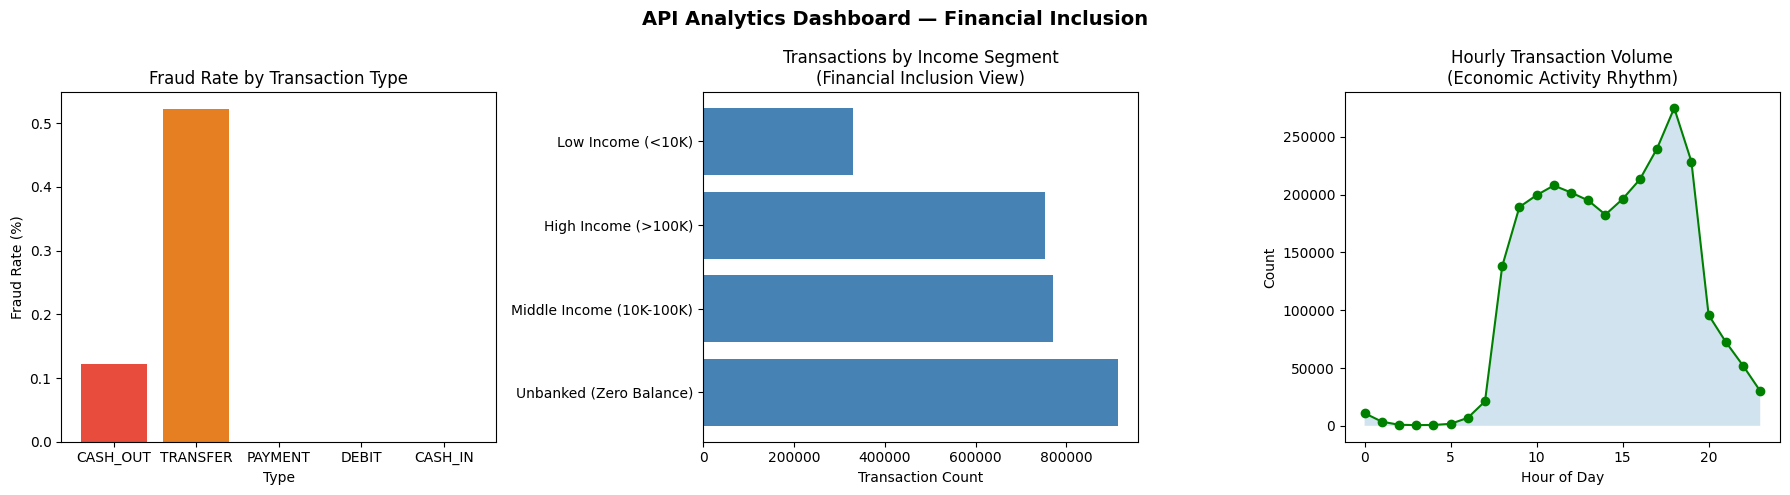

✅ API dashboard saved.


In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# Fetch data via API
fraud_data     = requests.get('http://localhost:5000/api/analyze/fraud').json()['data']
inclusion_data = requests.get('http://localhost:5000/api/analyze/inclusion').json()['data']
hourly_data    = requests.get('http://localhost:5000/api/analyze/hourly').json()['data']

fraud_df     = pd.DataFrame(fraud_data['fraud_by_type'])
inclusion_df = pd.DataFrame(inclusion_data['segments'])
hourly_df    = pd.DataFrame(hourly_data['hourly_breakdown'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('API Analytics Dashboard — Financial Inclusion', fontsize=14, fontweight='bold')

axes[0].bar(fraud_df['type'], fraud_df['fraud_rate_pct'], color=['#e74c3c','#e67e22','#2ecc71','#3498db','#9b59b6'])
axes[0].set_title('Fraud Rate by Transaction Type')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Fraud Rate (%)')

axes[1].barh(inclusion_df['income_segment'], inclusion_df['transaction_count'], color='steelblue')
axes[1].set_title('Transactions by Income Segment\n(Financial Inclusion View)')
axes[1].set_xlabel('Transaction Count')

axes[2].plot(hourly_df['hour_of_day'], hourly_df['transaction_count'], marker='o', color='green')
axes[2].set_title('Hourly Transaction Volume\n(Economic Activity Rhythm)')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Count')
axes[2].fill_between(hourly_df['hour_of_day'], hourly_df['transaction_count'], alpha=0.2)

plt.tight_layout()
plt.savefig('api_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ API dashboard saved.')

In [18]:
print(f'\n🌐 Your public API URL: {BASE_URL}')
print('Share this URL to access the API from any device until the session ends.')
print('\nExample curl commands:')
print(f'  curl {BASE_URL}/health')
print(f'  curl {BASE_URL}/api/analyze/fraud')
print(f"  curl -X POST {BASE_URL}/api/predict/fraud -H 'Content-Type: application/json' -d '{{\"type\":\"TRANSFER\",\"amount\":500000,\"oldbalanceOrg\":500000,\"newbalanceOrig\":0,\"oldbalanceDest\":0,\"newbalanceDest\":500000}}'")


🌐 Your public API URL: 
Share this URL to access the API from any device until the session ends.

Example curl commands:
  curl /health
  curl /api/analyze/fraud
  curl -X POST /api/predict/fraud -H 'Content-Type: application/json' -d '{"type":"TRANSFER","amount":500000,"oldbalanceOrg":500000,"newbalanceOrig":0,"oldbalanceDest":0,"newbalanceDest":500000}'
